In [ ]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "sayan2807/uav-cropped-labeled-soyabean-leaf-image-dataset"
)

print("Path to dataset files:", path)

Mounting files to /kaggle/input/datasets/sayan2807/uav-cropped-labeled-soyabean-leaf-image-dataset...
Path to dataset files: /kaggle/input/datasets/sayan2807/uav-cropped-labeled-soyabean-leaf-image-dataset


In [ ]:
import torch

PATH = (
    "/kaggle/input/models/sayan2807/convnext/pytorch/default/1/best_convnext_model.pth"
)

ckpt = torch.load(PATH, map_location="cpu")

print(type(ckpt))

if isinstance(ckpt, dict):
    print("\nKeys:")
    print(list(ckpt.keys())[:20])

<class 'collections.OrderedDict'>

Keys:
['features.0.0.weight', 'features.0.0.bias', 'features.0.1.weight', 'features.0.1.bias', 'features.1.0.layer_scale', 'features.1.0.block.0.weight', 'features.1.0.block.0.bias', 'features.1.0.block.2.weight', 'features.1.0.block.2.bias', 'features.1.0.block.3.weight', 'features.1.0.block.3.bias', 'features.1.0.block.5.weight', 'features.1.0.block.5.bias', 'features.1.1.layer_scale', 'features.1.1.block.0.weight', 'features.1.1.block.0.bias', 'features.1.1.block.2.weight', 'features.1.1.block.2.bias', 'features.1.1.block.3.weight', 'features.1.1.block.3.bias']


In [3]:
import torchvision.models as models

model = models.convnext_tiny()

print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1000, bias=True)
)


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import random
import shutil
import warnings
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# PATHS
# ============================================================

DATASET_PATH = (
    "/kaggle/input/datasets/sayan2807/uav-cropped-labeled-soyabean-leaf-image-dataset"
)

MODEL_PATH = (
    "/kaggle/input/models/sayan2807/convnext/pytorch/default/1/best_convnext_model.pth"
)

WORKING_DIR = "/kaggle/working"

SPLIT_DIR = os.path.join(WORKING_DIR, "uav_split_dataset")

BEST_MODEL_PATH = os.path.join(WORKING_DIR, "best_uav_convnext.pth")

# ============================================================
# TRAINING PARAMS
# ============================================================

IMG_SIZE = 224

BATCH_SIZE = 64

HEAD_EPOCHS = 5

FINETUNE_EPOCHS = 10

HEAD_LR = 1e-4

FINETUNE_LR = 1e-5

NUM_WORKERS = 2

# ============================================================

print("=" * 60)
print("DEVICE:", DEVICE)
print("DATASET:", DATASET_PATH)
print("MODEL:", MODEL_PATH)
print("=" * 60)

DEVICE: cuda
DATASET: /kaggle/input/datasets/sayan2807/uav-cropped-labeled-soyabean-leaf-image-dataset
MODEL: /kaggle/input/models/sayan2807/convnext/pytorch/default/1/best_convnext_model.pth


In [ ]:
# ============================================================
# CREATE DATASET SPLIT
# ============================================================

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

classes = sorted(
    [
        d
        for d in os.listdir(DATASET_PATH)
        if os.path.isdir(os.path.join(DATASET_PATH, d))
    ]
)

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

print("Classes Found:")
print(classes)

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)

    images = [
        os.path.join(cls_path, img)
        for img in os.listdir(cls_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    train_imgs, temp_imgs = train_test_split(
        images, test_size=0.30, random_state=SEED, shuffle=True
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.50, random_state=SEED, shuffle=True
    )

    split_map = {"train": train_imgs, "val": val_imgs, "test": test_imgs}

    for split_name, img_list in split_map.items():
        for img_path in tqdm(img_list, desc=f"{cls}-{split_name}"):
            shutil.copy2(img_path, os.path.join(SPLIT_DIR, split_name, cls))

print("\nDataset Split Completed")

Classes Found:
['Healthy', 'Mosaic', 'Rust', 'Semilooper']


Healthy-train:   0%|          | 0/5866 [00:00<?, ?it/s]

Healthy-val:   0%|          | 0/1257 [00:00<?, ?it/s]

Healthy-test:   0%|          | 0/1258 [00:00<?, ?it/s]

Mosaic-train:   0%|          | 0/11977 [00:00<?, ?it/s]

...

Rust-test:   0%|          | 0/1543 [00:00<?, ?it/s]

Semilooper-train:   0%|          | 0/17992 [00:00<?, ?it/s]

Semilooper-val:   0%|          | 0/3856 [00:00<?, ?it/s]

Semilooper-test:   0%|          | 0/3856 [00:00<?, ?it/s]


Dataset Split Completed


In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# ============================================================
# DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "train"), transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "val"), transform=val_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test"), transform=val_transform
)

print(train_dataset.classes)

['Healthy', 'Mosaic', 'Rust', 'Semilooper']


In [ ]:
# ============================================================
# WEIGHTED SAMPLER
# ============================================================

targets = train_dataset.targets

class_counts = np.bincount(targets)

print("Class Counts:")
print(class_counts)

class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)

sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Class Counts:
[ 5866 11977  7198 17992]
Train: 43033
Val  : 9221
Test : 9224


In [ ]:
# ============================================================
# LOAD CONVNEXT
# ============================================================

model = models.convnext_tiny()

# Original classifier
model.classifier[2] = nn.Linear(768, 6)

state_dict = torch.load(MODEL_PATH, map_location="cpu")

model.load_state_dict(state_dict)

print("6-Class Weights Loaded")

# ============================================================
# REPLACE FINAL LAYER
# ============================================================

model.classifier[2] = nn.Linear(768, 4)

model = model.to(DEVICE)

print("Converted To 4-Class UAV Model")

6-Class Weights Loaded
Converted To 4-Class UAV Model


In [ ]:
# ============================================================
# FREEZE BACKBONE
# ============================================================

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

print("Backbone Frozen")
print("Classifier Trainable")

# ============================================================
# LOSS
# ============================================================

class_weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float32)

class_weights = class_weights / class_weights.sum()

class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(model.classifier.parameters(), lr=HEAD_LR, weight_decay=1e-4)

# ============================================================
# AMP
# ============================================================

scaler = torch.cuda.amp.GradScaler()

print("Setup Complete")

Backbone Frozen
Classifier Trainable
Setup Complete


In [ ]:
# ============================================================
# VALIDATION
# ============================================================


def validate_model(model, loader):

    model.eval()

    total_loss = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)

            y_true.extend(labels.cpu().numpy())

            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    return (total_loss / len(loader), acc)

In [ ]:
# ============================================================
# TRAIN CLASSIFIER HEAD
# ============================================================

best_acc = 0

print("\n")
print("=" * 60)
print("TRAINING CLASSIFIER HEAD")
print("=" * 60)

for epoch in range(HEAD_EPOCHS):
    model.train()

    running_loss = 0

    loop = tqdm(
        train_loader, total=len(train_loader), desc=f"Epoch {epoch + 1}/{HEAD_EPOCHS}"
    )

    for images, labels in loop:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        loop.set_postfix(loss=f"{loss.item():.4f}")

    val_loss, val_acc = validate_model(model, val_loader)

    print(
        f"\nEpoch {epoch + 1}"
        f" | Train Loss={running_loss / len(train_loader):.4f}"
        f" | Val Loss={val_loss:.4f}"
        f" | Val Acc={val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc

        torch.save(model.state_dict(), "/kaggle/working/head_stage_best.pth")

        print("Best Model Saved")

print("\nBest Validation Accuracy:", best_acc)



TRAINING CLASSIFIER HEAD


Epoch 1/5:   0%|          | 0/673 [00:00<?, ?it/s]


Epoch 1 | Train Loss=0.8303 | Val Loss=0.6956 | Val Acc=0.7447
Best Model Saved


Epoch 2/5:   0%|          | 0/673 [00:00<?, ?it/s]


Epoch 2 | Train Loss=0.5174 | Val Loss=0.5035 | Val Acc=0.8175
Best Model Saved


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af81c9d5800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7af81c9d5800>
^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^^
^ ^  ^ ^  ^ ^^^^^^^


Epoch 3 | Train Loss=0.4200 | Val Loss=0.4315 | Val Acc=0.8405
Best Model Saved


Epoch 4/5:   0%|          | 0/673 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af81c9d5800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af81c9d5800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Epoch 5 | Train Loss=0.3500 | Val Loss=0.3713 | Val Acc=0.8587
Best Model Saved

Best Validation Accuracy: 0.8586921158225789


In [ ]:
# ============================================================
# LOAD BEST HEAD MODEL
# ============================================================

model.load_state_dict(torch.load("/kaggle/working/head_stage_best.pth"))

# ============================================================
# KEEP FROZEN
# ============================================================

for param in model.parameters():
    param.requires_grad = False

# ============================================================
# UNFREEZE LAST BLOCK
# ============================================================

for param in model.features[7].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

print("Last ConvNeXt Stage Unfrozen")

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINETUNE_LR,
    weight_decay=1e-4,
)

Last ConvNeXt Stage Unfrozen


In [ ]:
# ============================================================
# FINETUNING
# ============================================================

best_acc = 0

print("\n")
print("=" * 60)
print("FINE TUNING UAV MODEL")
print("=" * 60)

for epoch in range(FINETUNE_EPOCHS):
    model.train()

    running_loss = 0

    loop = tqdm(
        train_loader,
        total=len(train_loader),
        desc=f"FineTune {epoch + 1}/{FINETUNE_EPOCHS}",
    )

    for images, labels in loop:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        loop.set_postfix(loss=f"{loss.item():.4f}")

    val_loss, val_acc = validate_model(model, val_loader)

    print(
        f"\nEpoch {epoch + 1}"
        f" | Train={running_loss / len(train_loader):.4f}"
        f" | Val={val_loss:.4f}"
        f" | Acc={val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best UAV Model Saved")

print("\nFinal Best Accuracy:", best_acc)



FINE TUNING UAV MODEL


FineTune 1/10:   0%|          | 0/673 [00:00<?, ?it/s]


Epoch 1 | Train=0.2988 | Val=0.2572 | Acc=0.9017
Best UAV Model Saved


FineTune 2/10:   0%|          | 0/673 [00:00<?, ?it/s]


Epoch 2 | Train=0.2453 | Val=0.2356 | Acc=0.9071
Best UAV Model Saved


...

FineTune 9/10:   0%|          | 0/673 [00:00<?, ?it/s]


Epoch 9 | Train=0.1435 | Val=0.1495 | Acc=0.9423
Best UAV Model Saved


FineTune 10/10:   0%|          | 0/673 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7af81c9d5800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7af81c9d5800>if w.is_alive():
 
  Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() ^^^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():^
^ ^ ^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^^ ^ ^ ^ ^ ^^ 
   File "/usr/


Epoch 10 | Train=0.1383 | Val=0.1536 | Acc=0.9405

Final Best Accuracy: 0.9423056067671619


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

import numpy as np

# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(torch.load(BEST_MODEL_PATH))

model.eval()

y_true = []
y_pred = []
y_scores = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())

        y_pred.extend(preds.cpu().numpy())

        y_scores.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

print("=" * 60)
print("TEST RESULTS")
print("=" * 60)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average="weighted")

recall = recall_score(y_true, y_pred, average="weighted")

f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

try:
    roc_auc = roc_auc_score(y_true, y_scores, multi_class="ovr")

    print(f"ROC-AUC   : {roc_auc:.4f}")

except:
    print("ROC-AUC could not be computed")

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_true, y_pred, target_names=test_dataset.classes))

Testing:   0%|          | 0/145 [00:00<?, ?it/s]

TEST RESULTS
Accuracy  : 0.9361
Precision : 0.9396
Recall    : 0.9361
F1 Score  : 0.9362
ROC-AUC   : 0.9928


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.92      0.99      0.95      1258
      Mosaic       0.95      0.84      0.89      2567
        Rust       0.81      0.92      0.86      1543
  Semilooper       1.00      0.99      0.99      3856

    accuracy                           0.94      9224
   macro avg       0.92      0.93      0.92      9224
weighted avg       0.94      0.94      0.94      9224



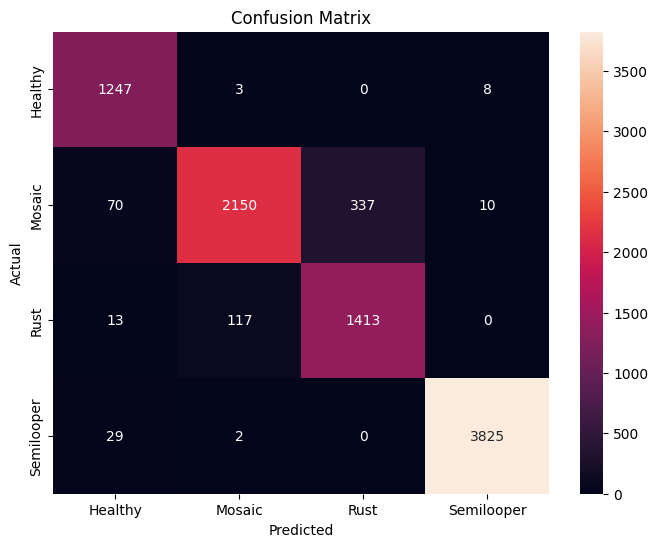

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes,
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
FINAL_MODEL_PATH = "/kaggle/working/uav_finetuned_convnext.pth"

torch.save(model.state_dict(), FINAL_MODEL_PATH)

print("Saved:")
print(FINAL_MODEL_PATH)

Saved:
/kaggle/working/uav_finetuned_convnext.pth
